In [5]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
import scipy as sp

In [6]:
# create transfer function

m = 60 # mass in kilograms
g = 9.81 # acceleration due to gravity, m/s^2
ta = 0.1598 #axial torque, kg * m
tr = ta # rotational torque, kg * m
fv = m*g # vertical force, N
fn = fv + m*g # normal force, N
jw = 0.21 # rotational inertia, kg * m^2
mu = 0.4 # kinetic coefficient of friction, unitless
ja = 6.434e-9 #moment of axial inertia, m^4
k = 3*0.11/0.05919 # spring constant, N/m
b = 2*np.sqrt(m*k) #dampening coefficient, Ns/m

A = np.array([[0, 1, 0, 0], 
              [-k/m, -b/m, k/m, b/m],
              [0, 0, 1, 0],
              [0, 0, 0, 0]])

B = np.array([[1/m], [0], [1/m], [0]])

C = np.array([1, 0, 0, 0])

D = np.array([0])

P = ct.ss(A, B, C, D)

print('A matrix:\n', P.A)
print('\nB matrix:\n', P.B)
print('\nC matrix:\n', P.C)
print('\nD matrix:\n', P.D)

A matrix:
 [[ 0.          1.          0.          0.        ]
 [-0.0929211  -0.60965925  0.0929211   0.60965925]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          0.        ]]

B matrix:
 [[0.01666667]
 [0.        ]
 [0.01666667]
 [0.        ]]

C matrix:
 [[1. 0. 0. 0.]]

D matrix:
 [[0.]]


In [54]:
cont = ct.ctrb(P.A, P.B)
print(cont)
print(np.linalg.matrix_rank(cont))

[[0.01666667 0.         0.         0.00154869]
 [0.         0.         0.00154869 0.00060451]
 [0.01666667 0.01666667 0.01666667 0.01666667]
 [0.         0.         0.         0.        ]]
3


In [7]:
# to transfer function
P_tf = ct.ss2tf(P)
print(P_tf)


 0.01667 s^3 - 0.006506 s^2 - 0.008612 s
-----------------------------------------
s^4 - 0.3903 s^3 - 0.5167 s^2 - 0.09292 s



C:\Users\bpele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\margins.py:378: RuntimeWarning: invalid value encountered in less_equal
  w_180 = w_180[w180_resp <= 0.]
C:\Users\bpele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\margins.py:379: RuntimeWarning: invalid value encountered in less_equal
  w180_resp = w180_resp[w180_resp <= 0.]


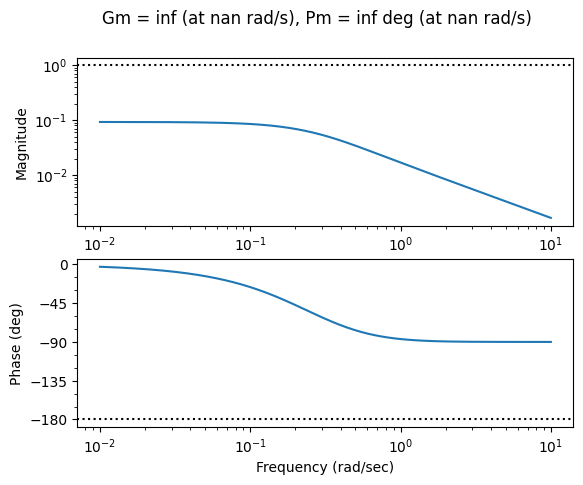

In [8]:
mag, phase, omega = ct.bode_plot(P_tf, margins=True)

(array([[-3.04829632e-01+0.j        , -3.04829622e-01+0.j        ,
          0.00000000e+00+0.j        ,  1.00000000e+00+0.j        ],
        [-3.04829632e-01+0.j        , -3.04829622e-01+0.j        ,
          0.00000000e+00+0.j        ,  1.00000000e+00+0.j        ],
        [-3.05433436e-01-0.01726377j, -3.05433436e-01+0.01726377j,
          0.00000000e+00+0.j        ,  9.99930369e-01+0.j        ],
        [-3.06037321e-01-0.02440036j, -3.06037321e-01+0.02440036j,
          0.00000000e+00+0.j        ,  9.99860890e-01+0.j        ],
        [-3.06641282e-01-0.0298667j , -3.06641282e-01+0.0298667j ,
          0.00000000e+00+0.j        ,  9.99791565e-01+0.j        ],
        [-3.07245320e-01-0.03446685j, -3.07245320e-01+0.03446685j,
          0.00000000e+00+0.j        ,  9.99722391e-01+0.j        ],
        [-3.09662225e-01-0.04862867j, -3.09662225e-01+0.04862867j,
          0.00000000e+00+0.j        ,  9.99447207e-01+0.j        ],
        [-3.12080327e-01-0.05941657j, -3.12080327e-01+0

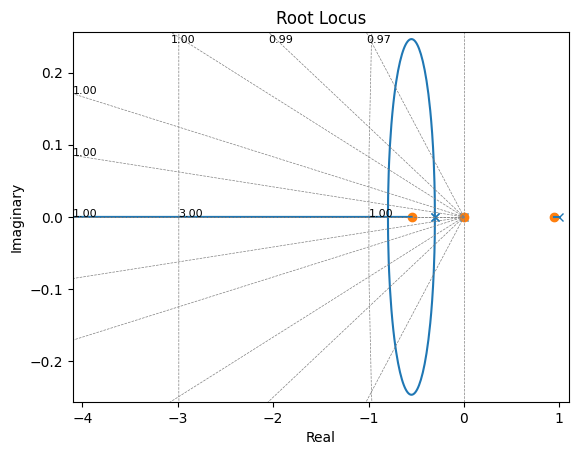

In [9]:
ct.root_locus(P_tf)

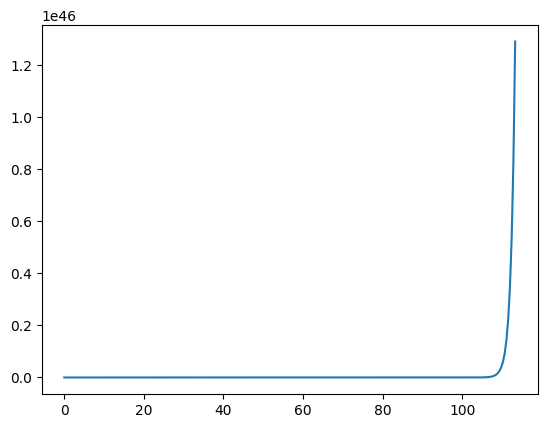

In [10]:
K_unity = 1
L = K_unity * P_tf
T = L / (1+L)

t, y = ct.step_response(T)
plt.plot(t, y)

In [11]:
poles = ct.poles(P_tf)
zeroes = ct.zeros(P_tf)

print("Poles: ", poles)
print("Zeroes: ", zeroes)

Poles:  [ 1.        +0.j -0.30482962+0.j -0.30482963+0.j  0.        +0.j]
Zeroes:  [ 0.94003924+0.j -0.54969849+0.j  0.        +0.j]


Cancel all poles, multiple derivative action


s^3 - 0.3903 s^2 - 0.5167 s - 0.09292
-------------------------------------
s^3 + 0.1097 s^2 - 0.7119 s - 0.2584


 0.01667 s^3 - 0.006506 s^2 - 0.008612 s
-----------------------------------------
s^4 - 0.3903 s^3 - 0.5167 s^2 - 0.09292 s


0.01667 s^6 - 0.01301 s^5 - 0.01469 s^4 + 0.005175 s^3 + 0.005055 s^2 + 0.0008003 s
-----------------------------------------------------------------------------------
  s^7 - 0.2807 s^6 - 1.271 s^5 - 0.1301 s^4 + 0.4585 s^3 + 0.1997 s^2 + 0.02401 s

poles: [ 1.        +0.j  0.94003924+0.j -0.54969849+0.j -0.5       +0.j
 -0.30482966+0.j -0.3048296 +0.j  0.        +0.j]
zeros: [ 1.        -3.19189120e-16j  0.94003924+3.25697721e-16j
 -0.54969849-6.23341078e-16j -0.30482962-4.95642026e-09j
 -0.30482964+4.95642102e-09j  0.        +0.00000000e+00j]


C:\Users\bpele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\xferfcn.py:1113: ComplexWarning: Casting complex values to real discards the imaginary part
  num[i, j, maxindex+1-len(numpoly):maxindex+1] = numpoly
C:\Users\bpele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\statesp.py:114: ComplexWarning: Casting complex values to real discards the imaginary part
  arr = np.array(data, dtype=float)


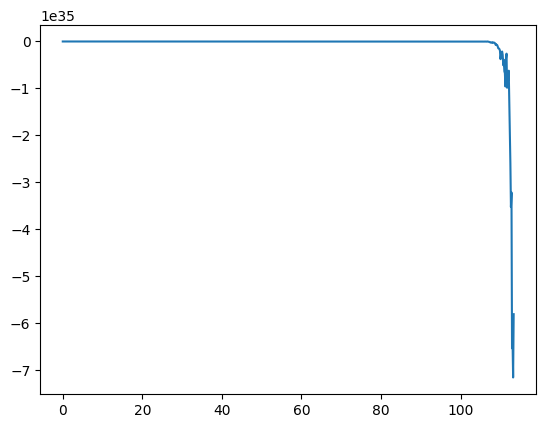

In [53]:
K = ct.tf([1, -poles[0]], [1]) * ct.tf([1], [1, -zeroes[0]]) * ct.tf([1], [1, -zeroes[1]]) * ct.tf([1, -poles[1]], 1) * ct.tf([1, -poles[2]], 1) * ct.tf(1, [1, 0.5])
print(K)

L = K * P_tf
print(P_tf)
print(L)
print(f"poles: {ct.poles(L)}")
print(f"zeros: {ct.zeros(L)}")
T = L / (1+L)

t, y = ct.step_response(T)
plt.plot(t, y)


C:\Users\bpele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\rlocus.py:308: ComplexWarning: Casting complex values to real discards the imaginary part
  false_gain = float(den.coeffs[0]) / float(num.coeffs[0])


(array([[-1.00000000e+03+7.83863015e-15j, -9.99983332e+02-7.79389326e-15j,
         -3.13163599e-01+6.33482848e-02j, ...,
          9.40039414e-01-5.14294175e-08j,  9.99999942e-01+3.49118715e-08j,
          1.00000006e+00-3.49114913e-08j],
        [-1.00000000e+03-5.46876793e-14j, -9.99742744e+02+5.46760105e-14j,
         -4.33457565e-01+2.15555668e-01j, ...,
          9.40039241e-01-5.90619586e-07j,  9.99999997e-01+6.39219799e-07j,
          1.00000000e+00-6.39219695e-07j],
        [-1.00000000e+03+1.10172643e-14j, -9.99502040e+02-1.10041048e-14j,
         -5.53809476e-01+2.44895387e-01j, ...,
          9.40039238e-01-4.39372986e-07j,  1.00000000e+00+4.51032939e-07j,
          9.99999998e-01-4.51032973e-07j],
        ...,
        [-1.00000000e+03-7.20592897e-19j, -5.00029980e+02+6.51264511e+03j,
         -5.49699897e-01-4.89000574e-17j, ...,
          9.40039238e-01+6.04763251e-07j,  1.00000000e+00-6.46073816e-07j,
          1.00000000e+00+6.46073828e-07j],
        [-1.00000000e+03+8.

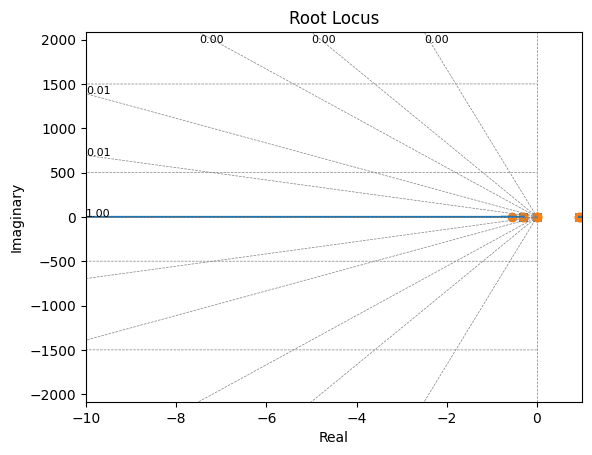

In [39]:
ct.root_locus(T, xlim=[-10, 1])

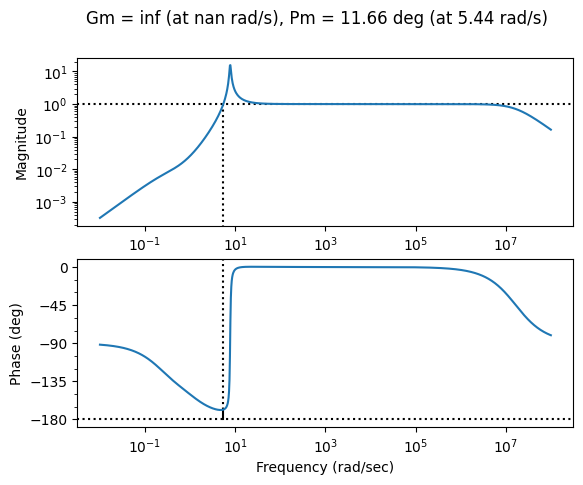

In [14]:
mag, phase, omega = ct.bode_plot(T, margins=True)

TypeError: Can't convert given type to TransferFunction system.

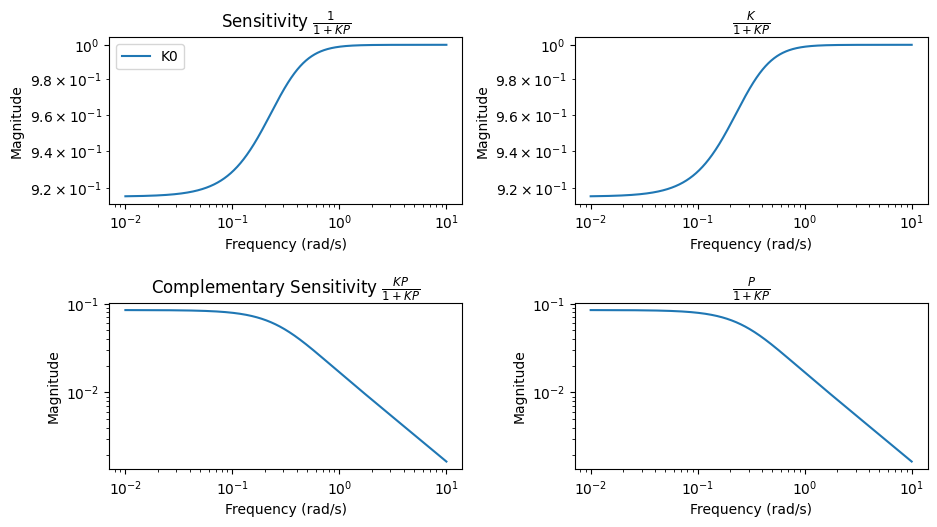

In [24]:
def plot_gang_of_four(P,K):
    num_sys = len(K)
    fig, ax = plt.subplots(2,2, figsize=(10,6))
    fig.tight_layout(pad=5.0)
    for ii in range(num_sys):
        T = P*K[ii]/(1+P*K[ii])
        S = 1/(1+P*K[ii])
        SK = K[ii]*S
        SP = P*S
        mag_S, phase_S, w_S = ct.bode_plot(S,plot=False)
        mag_T, phase_T, w_T = ct.bode_plot(T,plot=False)
        mag_SK, phase_SK, w_SK = ct.bode_plot(SK,plot=False)
        mag_SP, phase_SP, w_SP = ct.bode_plot(SP,plot=False)
        label_str = 'K' + str(ii)
        ax[0,0].loglog(w_S,mag_S, label=label_str)
        ax[0,0].set_title(r'Sensitivity $\frac{1}{1+KP}$')
        ax[0,0].legend()
        ax[0,0].set_xlabel('Frequency (rad/s)')
        ax[0,0].set_ylabel('Magnitude')
        ax[1,0].loglog(w_T,mag_T)
        ax[1,0].set_title(r'Complementary Sensitivity $\frac{KP}{1+KP}$')
        ax[1,0].set_xlabel('Frequency (rad/s)')
        ax[1,0].set_ylabel('Magnitude')
        ax[0,1].loglog(w_SK,mag_SK)
        ax[0,1].set_title(r'$\frac{K}{1+KP}$')
        ax[0,1].set_xlabel('Frequency (rad/s)')
        ax[0,1].set_ylabel('Magnitude')
        ax[1,1].loglog(w_SP,mag_SP)
        ax[1,1].set_title(r'$\frac{P}{1+KP}$')
        ax[1,1].set_xlabel('Frequency (rad/s)')
        ax[1,1].set_ylabel('Magnitude')
    return fig, ax
K_arr = [ ]
K_arr.append(ct.tf([1], [1]))
K_arr.append(K)
fig, ax = plot_gang_of_four(P_tf,K_arr) #P is the plant, K is your controller

Wonderful! Now try adding in lead/lag controllers to fix that phase margin